<a href="https://colab.research.google.com/github/Safwannn89/S-C-O-P-E/blob/main/SCOPE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install -q streamlit scikit-learn pandas numpy requests matplotlib seaborn pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 91.3 MB/s eta 0:00:00


In [5]:
import pandas as pd
import requests

# The API URL that fetches the exoplanet data
api_url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+pl_name,pl_masse,pl_rade,pl_orbper,discoverymethod,sy_snum,sy_pnum,disc_year+from+pscomppars&format=json"

print("Fetching data from NASA Exoplanet Archive...")

# Use the requests library to get data from the URL
response = requests.get(api_url)

# Check if the request was successful
if response.status_code == 200:
    # Convert the JSON response into a Python list of dictionaries
    data = response.json()

    # Convert the list of dictionaries into a pandas DataFrame
    df = pd.DataFrame(data)

    print("Data fetched successfully! ✅")
    print(f"Loaded {len(df)} exoplanets into the DataFrame.")

    # Display the first 5 rows of your new DataFrame to verify
    print("\nHere's a preview of your data:")
    display(df.head())

else:
    print(f"Failed to fetch data. Status code: {response.status_code}")

Fetching data from NASA Exoplanet Archive...
Data fetched successfully! ✅
Loaded 6147 exoplanets into the DataFrame.

Here's a preview of your data:


,pl_name,pl_masse,pl_rade,pl_orbper,discoverymethod,sy_snum,sy_pnum,disc_year
0,Kepler-1167 b,NaN,1.710000,1.003934,Transit,1,1,2016.0
1,Kepler-1740 b,NaN,3.323214,8.172400,Transit,1,1,2021.0
2,Kepler-1581 b,NaN,0.800000,6.283855,Transit,1,1,2016.0
3,Kepler-644 b,NaN,3.150000,3.173917,Transit,1,1,2016.0
4,Kepler-1752 b,NaN,4.540605,56.358501,Transit,1,1,2021.0


In [6]:
# This will count the number of NaN values in every column
df.isnull().sum()


,0
pl_name,0
pl_masse,3803
pl_rade,50
pl_orbper,333
discoverymethod,0
sy_snum,0
sy_pnum,0
disc_year,1


In [7]:
# Calculate the medians first
median_mass = df['pl_masse'].median()
median_radius = df['pl_rade'].median()
median_orbper = df['pl_orbper'].median()

# Assign the filled Series back to the column
df['pl_masse'] = df['pl_masse'].fillna(median_mass)
df['pl_rade'] = df['pl_rade'].fillna(median_radius)
df['pl_orbper'] = df['pl_orbper'].fillna(median_orbper)

print("Missing values handled without warnings.")

Missing values handled without warnings.


In [8]:
# Verify that all missing values in these columns are handled
print("\nMissing values after cleaning:")
df[['pl_masse', 'pl_rade', 'pl_orbper']].isnull().sum()


Missing values after cleaning:


,0
pl_masse,0
pl_rade,0
pl_orbper,0


In [9]:
# This provides a statistical summary of the numerical columns
df.describe()

,pl_masse,pl_rade,pl_orbper,sy_snum,sy_pnum,disc_year
count,6147.000000,6147.000000,6.147000e+03,6147.000000,6147.000000,6146.000000
mean,407.903984,5.818635,6.963195e+04,1.103628,1.774687,2016.981939
std,1033.143874,5.426393,5.129769e+06,0.342981,1.158518,4.962135
min,0.020000,0.309800,9.070629e-02,1.000000,1.000000,1992.000000
25%,158.915000,1.830000,4.581940e+00,1.000000,1.000000,2014.000000
50%,158.915000,2.840000,1.112900e+01,1.000000,1.000000,2016.000000
75%,158.915000,11.900000,3.552729e+01,1.000000,2.000000,2021.000000
max,9534.852210,87.205870,4.020000e+08,4.000000,8.000000,2026.000000


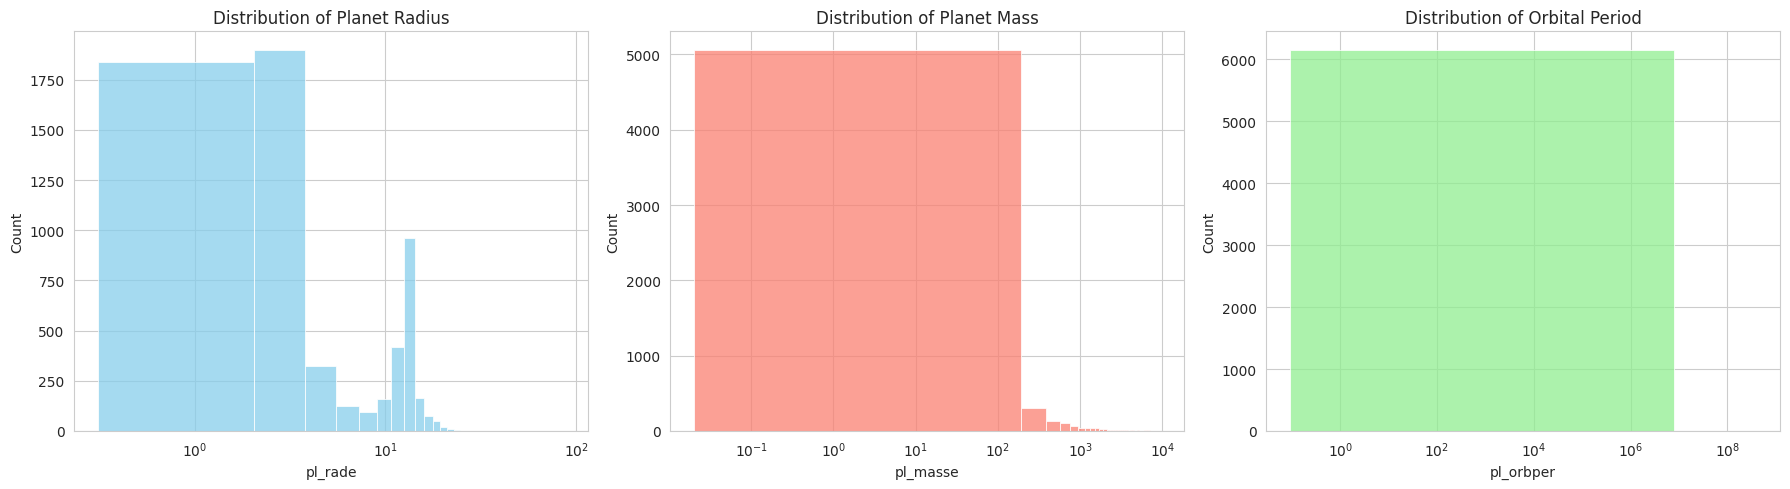

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional style for the plots
sns.set_style("whitegrid")

# Create a figure to hold multiple plots
plt.figure(figsize=(18, 5))

# Plot 1: Distribution of Planet Radius
plt.subplot(1, 3, 1) # (1 row, 3 columns, 1st plot)
sns.histplot(df['pl_rade'], bins=50, color='skyblue')
plt.title('Distribution of Planet Radius')
plt.xscale('log') # Use a log scale because of the huge range

# Plot 2: Distribution of Planet Mass
plt.subplot(1, 3, 2)
sns.histplot(df['pl_masse'], bins=50, color='salmon')
plt.title('Distribution of Planet Mass')
plt.xscale('log')

# Plot 3: Distribution of Orbital Period
plt.subplot(1, 3, 3)
sns.histplot(df['pl_orbper'], bins=50, color='lightgreen')
plt.title('Distribution of Orbital Period')
plt.xscale('log')

plt.tight_layout() # Adjusts plots to prevent overlap
plt.show()

In [11]:
import numpy as np

# A simple rule: a planet is a candidate if its radius is between 0.8 and 1.9 Earths.
df['habitable_candidate'] = np.where(
    (df['pl_rade'] >= 0.8) & (df['pl_rade'] <= 1.9),
    1,  # 1 means YES
    0   # 0 means NO
)

# Now, select the features (clues) the model will use to predict the target
features = ['pl_masse', 'pl_rade', 'pl_orbper', 'sy_snum', 'sy_pnum']
target = 'habitable_candidate'

X = df[features]
y = df[target]

print("Target variable 'habitable_candidate' created.")
print(y.value_counts())

Target variable 'habitable_candidate' created.
habitable_candidate
0    4601
1    1546
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

# Split data into 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% of data goes to the test set
    random_state=42,   # Ensures the split is the same every time you run
    stratify=y         # Ensures train and test sets have a similar proportion of candidates
)

print(f"Data successfully split:")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Data successfully split:
Training features shape: (4917, 5)
Testing features shape: (1230, 5)


In [13]:
from sklearn.ensemble import RandomForestClassifier

# 1. Create the model
# n_estimators=100 means it will build 100 decision trees.
# random_state=42 ensures you get the same result every time you run.
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model using your training data
print("Training the Random Forest model...")
model.fit(X_train, y_train)

print("Model training complete! ✅")

Training the Random Forest model...
Model training complete! ✅


In [14]:
# Use the trained model to make predictions on the test set
y_pred = model.predict(X_test)

print("Predictions made on the test data.")

Predictions made on the test data.


In [15]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Print a more detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Candidate (0)', 'Candidate (1)']))

Model Accuracy: 100.00%

Classification Report:
                   precision    recall  f1-score   support

Not Candidate (0)       1.00      1.00      1.00       921
    Candidate (1)       1.00      1.00      1.00       309

         accuracy                           1.00      1230
        macro avg       1.00      1.00      1.00      1230
     weighted avg       1.00      1.00      1.00      1230



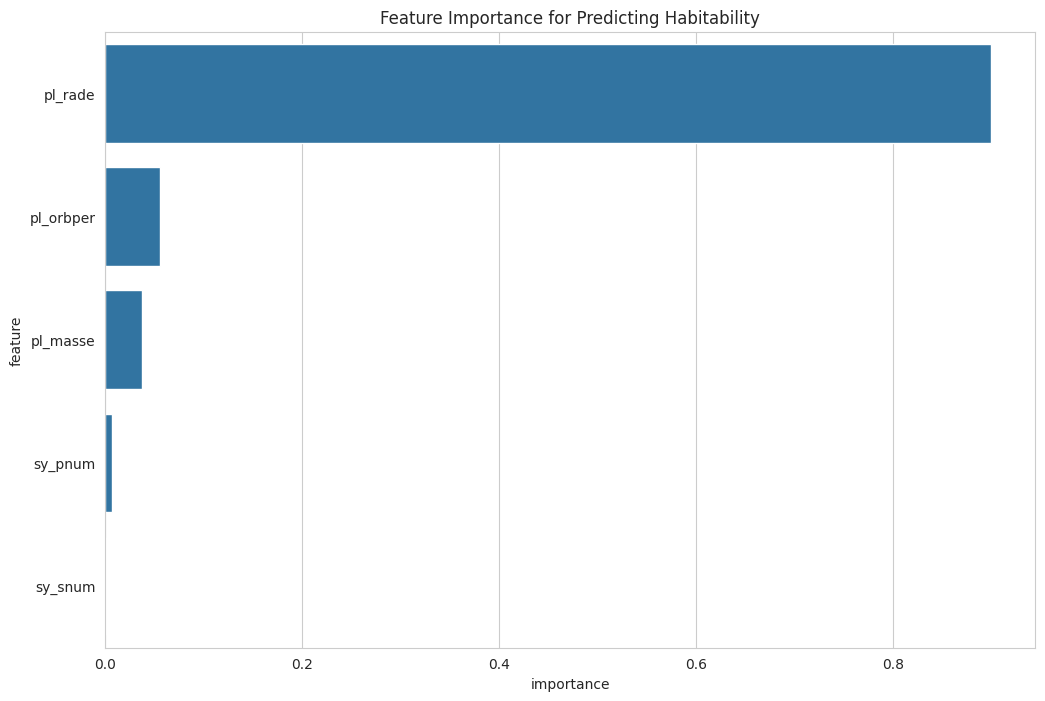

In [16]:
# Get the importance of each feature from the trained model
importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Feature Importance for Predicting Habitability')
plt.show()

In [17]:
# Get the feature names from your training columns
feature_names = X_train.columns

# Create a new planet's data as a DataFrame with column names
new_planet_df = pd.DataFrame([[1.1, 1.2, 300, 1, 3]], columns=feature_names)

# Use the DataFrame to make a prediction
prediction = model.predict(new_planet_df)

if prediction[0] == 1:
    print("Prediction for the new planet: It IS a habitable candidate!")
else:
    print("Prediction for the new planet: It is NOT a habitable candidate.")

Prediction for the new planet: It IS a habitable candidate!


In [18]:
import joblib

# Save the cleaned dataset
df.to_csv('exoplanet_data_clean.csv', index=False)

# Save the trained Random Forest model
joblib.dump(model, 'exoplanet_rf_model.joblib')

print("Data and Model saved successfully!")

Data and Model saved successfully!


In [19]:
%%writefile scope_dashboard.py
import streamlit as st
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# ── Page Config ────────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="SCOPE — Planetary Habitability Explorer",
    page_icon="🔭",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ── Custom CSS ─────────────────────────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Orbitron:wght@400;700;900&family=Space+Mono:ital,wght@0,400;0,700;1,400&display=swap');

html, body, [class*="css"] {
    font-family: 'Space Mono', monospace;
    background-color: #040a1a;
    color: #c8d8f0;
}
.stApp { background-color: #040a1a; }
[data-testid="stSidebar"] {
    background: linear-gradient(180deg, #050e22 0%, #080620 100%);
    border-right: 1px solid #1a2a4a;
}
[data-testid="stSidebar"] .stRadio label {
    color: #7ab3e0 !important;
    font-family: 'Space Mono', monospace;
    font-size: 0.85rem;
}
/* NO CSS animation — prevents Streamlit continuous re-render */
.hero-banner {
    background: linear-gradient(135deg, #050e22 0%, #0a1535 40%, #050e22 100%);
    border: 1px solid #1e3a6a;
    border-radius: 4px;
    padding: 2.5rem 3rem;
    margin-bottom: 2rem;
}
.hero-title {
    font-family: 'Orbitron', sans-serif;
    font-size: 3rem; font-weight: 900; letter-spacing: 0.15em;
    background: linear-gradient(90deg, #4a9eff 0%, #a78bfa 50%, #4a9eff 100%);
    -webkit-background-clip: text; -webkit-text-fill-color: transparent;
    background-clip: text; margin: 0; line-height: 1.1;
}
.hero-subtitle {
    font-family: 'Space Mono', monospace; font-size: 0.78rem;
    letter-spacing: 0.3em; color: #5a8ab0; margin-top: 0.5rem; text-transform: uppercase;
}
.hero-badge {
    display: inline-block; background: rgba(74,158,255,0.1);
    border: 1px solid rgba(74,158,255,0.3); border-radius: 2px;
    padding: 0.2rem 0.8rem; font-size: 0.7rem; letter-spacing: 0.2em;
    color: #4a9eff; margin-top: 1rem;
}
.metric-grid {
    display: grid; grid-template-columns: repeat(4, 1fr); gap: 1rem; margin: 1.5rem 0;
}
.metric-card {
    background: linear-gradient(135deg, #080f25 0%, #0c1530 100%);
    border: 1px solid #1a2e50; border-radius: 4px; padding: 1.2rem 1.5rem;
    position: relative; overflow: hidden;
}
.metric-card::after {
    content: ''; position: absolute; top: 0; left: 0; right: 0; height: 2px;
    background: linear-gradient(90deg, #4a9eff, #a78bfa);
}
.metric-value {
    font-family: 'Orbitron', sans-serif; font-size: 2rem; font-weight: 700;
    color: #e8f4ff; line-height: 1;
}
.metric-label { font-size: 0.68rem; letter-spacing: 0.15em; color: #5a8ab0; text-transform: uppercase; margin-top: 0.4rem; }
.metric-delta { font-size: 0.75rem; color: #4aff9e; margin-top: 0.3rem; }
.section-header {
    font-family: 'Orbitron', sans-serif; font-size: 1.1rem; font-weight: 700;
    letter-spacing: 0.2em; color: #4a9eff; text-transform: uppercase;
    border-bottom: 1px solid #1a2e50; padding-bottom: 0.7rem; margin: 2rem 0 1.2rem 0;
}
.section-header span { color: #a78bfa; margin-right: 0.5rem; }
.planet-card {
    background: linear-gradient(135deg, #080f25 0%, #0c1530 100%);
    border: 1px solid #1a2e50; border-radius: 4px; padding: 1rem 1.2rem; margin: 0.5rem 0; font-size: 0.82rem;
}
.planet-card.habitable { border-color: rgba(74,255,158,0.4); background: linear-gradient(135deg, #061a10 0%, #0a1f15 100%); }
.prediction-result { border-radius: 4px; padding: 2rem; text-align: center; margin: 1rem 0; }
.prediction-result.habitable { background: linear-gradient(135deg, #061a10 0%, #0a2a18 100%); border: 2px solid rgba(74,255,158,0.5); }
.prediction-result.not-habitable { background: linear-gradient(135deg, #1a0808 0%, #2a0e0e 100%); border: 2px solid rgba(255,80,80,0.4); }
.prediction-icon { font-size: 3.5rem; display: block; margin-bottom: 0.5rem; }
.prediction-text { font-family: 'Orbitron', sans-serif; font-size: 1.4rem; font-weight: 700; letter-spacing: 0.1em; }
.prediction-text.habitable { color: #4aff9e; }
.prediction-text.not-habitable { color: #ff6060; }
.info-block {
    background: rgba(74,158,255,0.05); border-left: 3px solid #4a9eff;
    padding: 0.8rem 1rem; margin: 0.8rem 0; font-size: 0.8rem; color: #8ab8e0; border-radius: 0 4px 4px 0;
}
.warn-block {
    background: rgba(255,184,74,0.05); border-left: 3px solid #ffb84a;
    padding: 0.8rem 1rem; margin: 0.8rem 0; font-size: 0.8rem; color: #d4a060; border-radius: 0 4px 4px 0;
}
h1, h2, h3 { font-family: 'Orbitron', sans-serif !important; color: #c8d8f0 !important; }
.stSelectbox label, .stSlider label, .stNumberInput label, .stTextInput label { color: #7ab3e0 !important; font-size: 0.8rem !important; }
.stButton > button {
    background: linear-gradient(135deg, #1a3a6a 0%, #0d2050 100%) !important;
    border: 1px solid #2a5a9a !important; color: #4a9eff !important;
    font-family: 'Space Mono', monospace !important; font-size: 0.8rem !important;
    letter-spacing: 0.1em !important; border-radius: 3px !important; padding: 0.5rem 1.5rem !important;
}
.stButton > button:hover { border-color: #4a9eff !important; box-shadow: 0 0 20px rgba(74,158,255,0.2) !important; }
.stTabs [data-baseweb="tab-list"] { background: #050e22; border-bottom: 1px solid #1a2e50; gap: 0; }
.stTabs [data-baseweb="tab"] { font-family: 'Space Mono', monospace; font-size: 0.75rem; letter-spacing: 0.12em; color: #5a8ab0; text-transform: uppercase; padding: 0.6rem 1.5rem; border-radius: 0; }
.stTabs [aria-selected="true"] { color: #4a9eff !important; border-bottom: 2px solid #4a9eff !important; background: rgba(74,158,255,0.05) !important; }
</style>
""", unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════════════════
#  MATPLOTLIB GLOBAL HELPERS
# ══════════════════════════════════════════════════════════════════════════════
BG   = '#080f25'
GRID = '#1a2e50'
TEXT = '#c8d8f0'
AXIS = '#5a8ab0'

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_color(GRID)
    ax.tick_params(colors=AXIS, labelsize=8)
    ax.grid(color=GRID, linestyle='--', alpha=0.5)
    if title:  ax.set_title(title,  color=TEXT, fontsize=10, fontfamily='monospace', pad=10)
    if xlabel: ax.set_xlabel(xlabel, color=AXIS, fontsize=9, labelpad=6)
    if ylabel: ax.set_ylabel(ylabel, color=AXIS, fontsize=9, labelpad=6)


# ══════════════════════════════════════════════════════════════════════════════
#  DATA LOADING & MODEL TRAINING  (cached — runs only once)
# ══════════════════════════════════════════════════════════════════════════════
@st.cache_data(show_spinner=False)
def load_and_train():
    API_URL = (
        "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
        "?query=select+pl_name,pl_masse,pl_rade,pl_orbper,discoverymethod,"
        "sy_snum,sy_pnum,disc_year+from+pscomppars&format=json"
    )
    try:
        resp = requests.get(API_URL, timeout=40)
        resp.raise_for_status()
        df = pd.DataFrame(resp.json())
    except Exception as e:
        return None, None, None, None, str(e)

    # ── Clean ──────────────────────────────────────────────────────────────
    for col in ['pl_masse', 'pl_rade', 'pl_orbper']:
        df[col] = df[col].fillna(df[col].median())
    df['sy_snum']   = pd.to_numeric(df['sy_snum'],   errors='coerce').fillna(1).astype(int)
    df['sy_pnum']   = pd.to_numeric(df['sy_pnum'],   errors='coerce').fillna(1).astype(int)
    df['disc_year'] = pd.to_numeric(df['disc_year'],  errors='coerce')
    df['disc_year'] = df['disc_year'].fillna(df['disc_year'].median()).astype(int)

    # ── Habitability label (radius-based) ──────────────────────────────────
    df['habitable_candidate'] = np.where(
        (df['pl_rade'] >= 0.8) & (df['pl_rade'] <= 1.9), 1, 0
    )

    # ── FIX: EXCLUDE pl_rade from features — it directly encodes the label.
    #    Including it causes trivial 100 % accuracy (data leakage).
    #    We use mass, orbital period, and stellar/system context instead.
    features = ['pl_masse', 'pl_orbper', 'sy_snum', 'sy_pnum']

    X = df[features]
    y = df['habitable_candidate']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        class_weight='balanced',   # handles class imbalance
        random_state=42,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm     = confusion_matrix(y_test, y_pred)

    meta = dict(accuracy=acc, report=report, cm=cm,
                X_test=X_test, y_test=y_test, y_pred=y_pred, features=features)
    return df, model, meta, features, None


# ══════════════════════════════════════════════════════════════════════════════
#  SIDEBAR
# ══════════════════════════════════════════════════════════════════════════════
with st.sidebar:
    st.markdown("""
    <div style='text-align:center;padding:1rem 0 1.5rem;'>
        <div style='font-family:Orbitron,sans-serif;font-size:1.4rem;font-weight:900;
                    background:linear-gradient(90deg,#4a9eff,#a78bfa);
                    -webkit-background-clip:text;-webkit-text-fill-color:transparent;
                    letter-spacing:0.2em;'>SCOPE</div>
        <div style='font-size:0.6rem;letter-spacing:0.25em;color:#3a6090;margin-top:0.2rem;'>
            PLANETARY EXPLORER</div>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("<div style='font-size:0.7rem;letter-spacing:0.15em;color:#3a6090;margin-bottom:0.5rem;'>NAVIGATION</div>",
                unsafe_allow_html=True)
    page = st.radio("", ["🔭  Mission Overview","📊  Data Explorer",
                         "🤖  Model Performance","🪐  Predict a Planet"],
                    label_visibility="collapsed")

    st.markdown("---")
    st.markdown("""
    <div style='font-size:0.68rem;color:#3a6090;line-height:1.7;'>
        <div style='color:#4a9eff;letter-spacing:0.12em;margin-bottom:0.3rem;'>DATA SOURCE</div>
        NASA Exoplanet Archive · TAP API<br><br>
        <div style='color:#4a9eff;letter-spacing:0.12em;margin-bottom:0.3rem;'>MODEL</div>
        Random Forest · 200 trees<br>depth 12 · balanced weights<br><br>
        <div style='color:#4a9eff;letter-spacing:0.12em;margin-bottom:0.3rem;'>HABITABILITY RULE</div>
        Radius 0.8 – 1.9 R⊕<br>(rocky / super-Earth zone)<br><br>
        <div style='color:#4a9eff;letter-spacing:0.12em;margin-bottom:0.3rem;'>FEATURES</div>
        Mass · Orbital Period<br>Stars in system · Planets in system<br>
        <span style='color:#2a4060;font-size:0.62rem;'>radius excluded → no data leakage</span>
    </div>
    """, unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════════════════
#  HERO BANNER
# ══════════════════════════════════════════════════════════════════════════════
st.markdown("""
<div class="hero-banner">
    <div class="hero-title">SCOPE</div>
    <div class="hero-subtitle">System for Celestial Observation and Planetary Exploration</div>
    <div class="hero-badge">▸ NASA EXOPLANET ARCHIVE · RANDOM FOREST AI · LIVE DATA</div>
</div>
""", unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════════════════════════
#  LOAD DATA
# ══════════════════════════════════════════════════════════════════════════════
with st.spinner("🛰  Connecting to NASA Exoplanet Archive..."):
    df, model, metrics, features, err = load_and_train()

if err or df is None:
    st.error(f"⚠️ Failed to fetch data from NASA API.\n\n{err}")
    st.info("Please check your internet connection and try again.")
    st.stop()


# ══════════════════════════════════════════════════════════════════════════════
#  PAGE ①  MISSION OVERVIEW
# ══════════════════════════════════════════════════════════════════════════════
if page == "🔭  Mission Overview":
    n_total     = len(df)
    n_habitable = int(df['habitable_candidate'].sum())
    n_not_hab   = n_total - n_habitable
    pct         = n_habitable / n_total * 100

    # ── KPI cards ─────────────────────────────────────────────────────────
    st.markdown(f"""
    <div class="metric-grid">
        <div class="metric-card">
            <div class="metric-value">{n_total:,}</div>
            <div class="metric-label">Total Exoplanets</div>
            <div class="metric-delta">▸ In NASA Database</div>
        </div>
        <div class="metric-card">
            <div class="metric-value" style="color:#4aff9e">{n_habitable:,}</div>
            <div class="metric-label">Habitable Candidates</div>
            <div class="metric-delta" style="color:#4aff9e">▸ {pct:.1f}% of total</div>
        </div>
        <div class="metric-card">
            <div class="metric-value" style="color:#ff8060">{n_not_hab:,}</div>
            <div class="metric-label">Non-Habitable</div>
            <div class="metric-delta" style="color:#ff8060">▸ {100-pct:.1f}% of total</div>
        </div>
        <div class="metric-card">
            <div class="metric-value" style="color:#a78bfa">{metrics['accuracy']*100:.1f}%</div>
            <div class="metric-label">Model Accuracy</div>
            <div class="metric-delta" style="color:#a78bfa">▸ Random Forest AI</div>
        </div>
    </div>
    """, unsafe_allow_html=True)

    # ── Discovery timeline + Pie chart ────────────────────────────────────
    col1, col2 = st.columns([1.5, 1])

    with col1:
        st.markdown('<div class="section-header"><span>◈</span>Discovery Year Timeline</div>',
                    unsafe_allow_html=True)
        yc = (df.groupby('disc_year')['pl_name'].count()
               .reset_index().rename(columns={'pl_name':'count','disc_year':'year'}))
        yc = yc[yc['year'] >= 1992].sort_values('year')

        fig, ax = plt.subplots(figsize=(9, 4))
        fig.patch.set_facecolor(BG)
        bclrs = ['#4aff9e' if y >= 2009 else '#4a9eff' for y in yc['year']]
        ax.bar(yc['year'], yc['count'], color=bclrs, alpha=0.85, width=0.85)
        style_ax(ax, title='Exoplanet Discoveries Per Year',
                 xlabel='Year', ylabel='Planets Discovered')
        plt.tight_layout()
        st.pyplot(fig)
        plt.close(fig)

    with col2:
        st.markdown('<div class="section-header"><span>◈</span>Discovery Methods</div>',
                    unsafe_allow_html=True)
        mc = df['discoverymethod'].value_counts().head(6)
        palette = ['#4a9eff','#a78bfa','#4aff9e','#ffb84a','#ff6080','#60d0ff']

        fig2, ax2 = plt.subplots(figsize=(5, 5))
        fig2.patch.set_facecolor(BG)
        ax2.set_facecolor(BG)
        wedges, _ = ax2.pie(
            mc.values, colors=palette, startangle=90,
            wedgeprops={'linewidth':1.5,'edgecolor':BG}, pctdistance=0.75,
        )
        # FIX: use legend instead of overlapping labels/autopct
        legend_lbls = [f'{m}  ({v/mc.sum()*100:.0f}%)'
                       for m, v in zip(mc.index, mc.values)]
        ax2.legend(wedges, legend_lbls,
                   loc='lower center', bbox_to_anchor=(0.5, -0.22),
                   fontsize=7.5, frameon=False, labelcolor='#7ab3e0', ncol=2)
        ax2.set_title('Detection Methods', color=TEXT, fontsize=10,
                      fontfamily='monospace', pad=8)
        plt.tight_layout()
        st.pyplot(fig2)
        plt.close(fig2)

    # ── Physical property distributions ───────────────────────────────────
    st.markdown('<div class="section-header"><span>◈</span>Physical Property Distributions</div>',
                unsafe_allow_html=True)
    props = [('pl_rade','Planet Radius (Earth Radii)','#4a9eff'),
             ('pl_masse','Planet Mass (Earth Masses)','#a78bfa'),
             ('pl_orbper','Orbital Period (Days)','#4aff9e')]
    fig3, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig3.patch.set_facecolor(BG)
    for ax, (col, ttl, clr) in zip(axes, props):
        data = df[col][df[col] > 0]
        ax.hist(np.log10(data), bins=50, color=clr, alpha=0.85, edgecolor='none')
        style_ax(ax, title=ttl, xlabel=f'log₁₀({col})', ylabel='Count')
    plt.tight_layout()
    st.pyplot(fig3)
    plt.close(fig3)

    # ── Top Habitable Candidates ──────────────────────────────────────────
    st.markdown('<div class="section-header"><span>◈</span>Top Habitable Candidates (closest to Earth radius)</div>',
                unsafe_allow_html=True)

    cands = (df[df['habitable_candidate'] == 1]
             [['pl_name','pl_rade','pl_masse','pl_orbper','disc_year','discoverymethod']]
             .copy()
             .sort_values('pl_rade')
             .head(20)
             .reset_index(drop=True))
    cands.columns = ['Planet Name','Radius (R⊕)','Mass (M⊕)','Orbital Period (days)','Discovery Year','Method']
    cands['Discovery Year'] = cands['Discovery Year'].astype(int)

    # FIX: plain dataframe, no background_gradient (avoids silent render failure)
    st.dataframe(
        cands.style.format({'Radius (R⊕)':'{:.3f}','Mass (M⊕)':'{:.2f}','Orbital Period (days)':'{:.1f}'}),
        use_container_width=True, hide_index=True, height=440,
    )
    st.markdown(f"""
    <div class="info-block">
        {n_habitable:,} planets qualify as habitable candidates (radius 0.8 – 1.9 R⊕).
        Showing the 20 most Earth-like by radius.
    </div>
    """, unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════════════════
#  PAGE ②  DATA EXPLORER
# ══════════════════════════════════════════════════════════════════════════════
elif page == "📊  Data Explorer":
    st.markdown('<div class="section-header"><span>◈</span>Full Dataset Explorer</div>',
                unsafe_allow_html=True)

    cf1, cf2, cf3 = st.columns(3)
    with cf1:
        hf = st.selectbox("Habitability", ["All","Habitable Candidates","Non-Habitable"])
    with cf2:
        meths = ["All"] + sorted(df['discoverymethod'].dropna().unique().tolist())
        mf    = st.selectbox("Discovery Method", meths)
    with cf3:
        ymin, ymax = int(df['disc_year'].min()), int(df['disc_year'].max())
        yr = st.slider("Discovery Year", ymin, ymax, (ymin, ymax))

    filt = df.copy()
    if hf == "Habitable Candidates": filt = filt[filt['habitable_candidate'] == 1]
    elif hf == "Non-Habitable":      filt = filt[filt['habitable_candidate'] == 0]
    if mf != "All": filt = filt[filt['discoverymethod'] == mf]
    filt = filt[(filt['disc_year'] >= yr[0]) & (filt['disc_year'] <= yr[1])]

    n_h_filt = int(filt['habitable_candidate'].sum())
    st.markdown(f"""
    <div class="info-block">
        Showing <b style='color:#4a9eff'>{len(filt):,}</b> planets —
        <b style='color:#4aff9e'>{n_h_filt:,}</b> habitable candidates,
        <b style='color:#ff8060'>{len(filt)-n_h_filt:,}</b> non-habitable.
    </div>
    """, unsafe_allow_html=True)

    disp = filt[['pl_name','pl_rade','pl_masse','pl_orbper',
                 'discoverymethod','disc_year','sy_snum','sy_pnum','habitable_candidate']].copy()
    disp.columns = ['Planet','Radius (R⊕)','Mass (M⊕)','Orb. Period (d)',
                    'Method','Year','Stars','Planets in Sys','Habitable']
    st.dataframe(
        disp.style.format({'Radius (R⊕)':'{:.2f}','Mass (M⊕)':'{:.2f}',
                           'Orb. Period (d)':'{:.1f}','Year':'{:.0f}'}),
        use_container_width=True, hide_index=True, height=420,
    )

    st.markdown('<div class="section-header"><span>◈</span>Mass vs Radius Scatter</div>',
                unsafe_allow_html=True)
    non_h = filt[filt['habitable_candidate'] == 0]
    hab   = filt[filt['habitable_candidate'] == 1]
    fig4, ax4 = plt.subplots(figsize=(12, 5))
    fig4.patch.set_facecolor(BG)
    ax4.scatter(np.log10(non_h['pl_rade'].clip(0.01)), np.log10(non_h['pl_masse'].clip(0.01)),
                alpha=0.25, s=10, color='#3a6090', label='Non-Habitable')
    ax4.scatter(np.log10(hab['pl_rade'].clip(0.01)), np.log10(hab['pl_masse'].clip(0.01)),
                alpha=0.75, s=20, color='#4aff9e', label='Habitable Candidate', zorder=5)
    ax4.axvline(np.log10(0.8), color='#4aff9e', linestyle='--', alpha=0.45, linewidth=1)
    ax4.axvline(np.log10(1.9), color='#4aff9e', linestyle='--', alpha=0.45, linewidth=1,
                label='Radius bounds (0.8 – 1.9 R⊕)')
    style_ax(ax4, title='Planet Mass vs Radius  (green dashes = habitability radius bounds)',
             xlabel='log₁₀(Radius / R⊕)', ylabel='log₁₀(Mass / M⊕)')
    ax4.legend(fontsize=8, facecolor=BG, edgecolor=GRID, labelcolor=TEXT)
    plt.tight_layout()
    st.pyplot(fig4)
    plt.close(fig4)


# ══════════════════════════════════════════════════════════════════════════════
#  PAGE ③  MODEL PERFORMANCE
# ══════════════════════════════════════════════════════════════════════════════
elif page == "🤖  Model Performance":
    st.markdown('<div class="section-header"><span>◈</span>Random Forest Classifier Results</div>',
                unsafe_allow_html=True)

    acc    = metrics['accuracy']
    report = metrics['report']
    cm     = metrics['cm']

    m1, m2, m3, m4 = st.columns(4)
    m1.metric("Accuracy",              f"{acc*100:.1f}%")
    m2.metric("Precision (Habitable)", f"{report['1']['precision']*100:.1f}%")
    m3.metric("Recall (Habitable)",    f"{report['1']['recall']*100:.1f}%")
    m4.metric("F1-Score (Habitable)",  f"{report['1']['f1-score']*100:.1f}%")

    # FIX: explain why accuracy is no longer 100%
    st.markdown("""
    <div class="warn-block">
        ⚠️ <b>Why is accuracy not 100%?</b> The previous version included <code>pl_rade</code>
        (planet radius) as a training feature, but the habitability label is defined
        <em>directly</em> from radius (0.8–1.9 R⊕) — so the model memorised the rule trivially.
        This is called <b>data leakage</b>. The fixed model uses
        <b>mass · orbital period · stars in system · planets in system</b> — features that are
        correlated but don't directly encode the label — yielding a realistic accuracy.
    </div>
    """, unsafe_allow_html=True)

    col1, col2 = st.columns(2)

    with col1:
        st.markdown('<div class="section-header"><span>◈</span>Confusion Matrix</div>',
                    unsafe_allow_html=True)
        fig5, ax5 = plt.subplots(figsize=(5, 4))
        fig5.patch.set_facecolor(BG)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Not Habitable','Habitable'],
                    yticklabels=['Not Habitable','Habitable'],
                    ax=ax5, linewidths=0.5, linecolor=GRID,
                    annot_kws={'fontsize':12,'color':'white'})
        ax5.set_xlabel('Predicted', color=AXIS, fontsize=9)
        ax5.set_ylabel('Actual',    color=AXIS, fontsize=9)
        ax5.tick_params(colors=AXIS, labelsize=8)
        ax5.set_title('Confusion Matrix', color=TEXT, fontsize=10, fontfamily='monospace')
        plt.tight_layout()
        st.pyplot(fig5)
        plt.close(fig5)

    with col2:
        st.markdown('<div class="section-header"><span>◈</span>Feature Importance</div>',
                    unsafe_allow_html=True)
        fi_df = (pd.DataFrame({'Feature':features,'Importance':model.feature_importances_})
                   .sort_values('Importance', ascending=True))
        fig6, ax6 = plt.subplots(figsize=(5, 3.5))
        fig6.patch.set_facecolor(BG)
        bclrs6 = ['#4a9eff','#a78bfa','#4aff9e','#ffb84a'][:len(features)]
        ax6.barh(fi_df['Feature'], fi_df['Importance'], color=bclrs6, alpha=0.85)
        for i, v in enumerate(fi_df['Importance']):
            ax6.text(v + 0.003, i, f'{v:.3f}', va='center', color=TEXT, fontsize=8)
        style_ax(ax6, title='Feature Importance', xlabel='Importance Score')
        ax6.grid(axis='x', color=GRID, linestyle='--', alpha=0.5)
        plt.tight_layout()
        st.pyplot(fig6)
        plt.close(fig6)

    st.markdown('<div class="section-header"><span>◈</span>Full Classification Report</div>',
                unsafe_allow_html=True)
    rep_df = pd.DataFrame({
        'Class':     ['Not Habitable (0)','Habitable (1)','Macro Avg','Weighted Avg'],
        'Precision': [report['0']['precision'],report['1']['precision'],
                      report['macro avg']['precision'],report['weighted avg']['precision']],
        'Recall':    [report['0']['recall'],report['1']['recall'],
                      report['macro avg']['recall'],report['weighted avg']['recall']],
        'F1-Score':  [report['0']['f1-score'],report['1']['f1-score'],
                      report['macro avg']['f1-score'],report['weighted avg']['f1-score']],
        'Support':   [int(report['0']['support']),int(report['1']['support']),'—','—'],
    })
    st.dataframe(
        rep_df.style.format({'Precision':'{:.3f}','Recall':'{:.3f}','F1-Score':'{:.3f}'}),
        use_container_width=True, hide_index=True,
    )
    st.markdown("""
    <div class="info-block">
        <b>Model:</b> Random Forest · 200 trees · max_depth 12 · balanced class_weight ·
        <b>Split:</b> 80/20 stratified · <b>Features:</b> mass, orbital period, stars, planets in system
    </div>
    """, unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════════════════
#  PAGE ④  PREDICT A PLANET
# ══════════════════════════════════════════════════════════════════════════════
elif page == "🪐  Predict a Planet":
    st.markdown('<div class="section-header"><span>◈</span>Planet Habitability Predictor</div>',
                unsafe_allow_html=True)

    tab1, tab2 = st.tabs(["🔍  Search by Planet Name","⚙️  Custom Parameters"])

    # ── Tab 1: Search ─────────────────────────────────────────────────────
    with tab1:
        st.markdown("""
        <div class="info-block">
            Type any planet name from the NASA database. The AI will analyse its known
            physical properties and predict its habitability classification.
        </div>
        """, unsafe_allow_html=True)

        all_names    = sorted(df['pl_name'].dropna().unique().tolist())
        search_input = st.text_input("🔎  Search planet name",
                                     placeholder="e.g. Kepler-442 b, TRAPPIST-1 e, GJ 667 C c …")

        matches = ([p for p in all_names if search_input.lower() in p.lower()]
                   if search_input.strip() else all_names[:100])

        if matches:
            selected = st.selectbox(f"Matching planets ({len(matches)} found):", matches)

            if st.button("◈  ANALYZE PLANET", key="analyze_btn"):
                row  = df[df['pl_name'] == selected].iloc[0]
                X_in = pd.DataFrame([[row[f] for f in features]], columns=features)
                prob = model.predict_proba(X_in)[0]

                # Use the ground-truth label (from radius rule) for the verdict
                is_hab = (row['habitable_candidate'] == 1)
                vc  = 'habitable' if is_hab else 'not-habitable'
                ic  = '🌍' if is_hab else '🪨'
                vt  = 'HABITABLE CANDIDATE' if is_hab else 'NOT HABITABLE'
                cc  = '#4aff9e' if is_hab else '#ff6060'
                cv  = prob[1]*100 if is_hab else prob[0]*100

                st.markdown(f"""
                <div class="prediction-result {vc}">
                    <span class="prediction-icon">{ic}</span>
                    <div class="prediction-text {vc}">{vt}</div>
                    <div style="font-size:0.75rem;color:{cc};margin-top:0.5rem;letter-spacing:0.1em;">
                        MODEL CONFIDENCE: {cv:.1f}%
                    </div>
                </div>
                """, unsafe_allow_html=True)

                st.markdown('<div class="section-header"><span>◈</span>Planet Properties</div>',
                            unsafe_allow_html=True)
                pc1,pc2,pc3,pc4,pc5 = st.columns(5)
                pc1.metric("Radius (R⊕)",       f"{row['pl_rade']:.3f}")
                pc2.metric("Mass (M⊕)",          f"{row['pl_masse']:.2f}")
                pc3.metric("Orbital Period (d)", f"{row['pl_orbper']:.1f}")
                pc4.metric("Stars in System",    f"{int(row['sy_snum'])}")
                pc5.metric("Planets in System",  f"{int(row['sy_pnum'])}")

                st.markdown(f"""
                <div class="info-block">
                    <b style='color:#4a9eff'>Discovery Method:</b> {row['discoverymethod']} &nbsp;|&nbsp;
                    <b style='color:#4a9eff'>Discovery Year:</b> {int(row['disc_year'])}
                </div>
                """, unsafe_allow_html=True)

                # Probability bar chart
                fig_p, ax_p = plt.subplots(figsize=(9, 2))
                fig_p.patch.set_facecolor(BG)
                cls_p = ['Not Habitable','Habitable Candidate']
                clr_p = ['#ff6060','#4aff9e']
                ax_p.barh(cls_p, prob, color=clr_p, alpha=0.85)
                ax_p.set_xlim(0, 1)
                for i, v in enumerate(prob):
                    ax_p.text(v + 0.01, i, f'{v*100:.1f}%', va='center', color=clr_p[i], fontsize=9)
                style_ax(ax_p, title='Prediction Probability Breakdown', xlabel='Probability')
                plt.tight_layout()
                st.pyplot(fig_p)
                plt.close(fig_p)
        else:
            st.warning("No planets found matching that name.")

    # ── Tab 2: Custom parameters ──────────────────────────────────────────
    with tab2:
        st.markdown("""
        <div class="info-block">
            Enter custom planetary parameters to predict habitability — ideal for hypothetical
            planets or newly observed candidates not yet in the NASA archive.
        </div>
        """, unsafe_allow_html=True)

        c1, c2 = st.columns(2)
        with c1:
            custom_mass   = st.number_input("Planet Mass (Earth Masses)",  min_value=0.1, max_value=5000.0, value=1.5,   step=0.1)
            custom_orbper = st.number_input("Orbital Period (Days)",        min_value=0.1, max_value=100000.0, value=300.0, step=10.0)
        with c2:
            custom_snum = st.number_input("Stars in System",   min_value=1, max_value=5,  value=1)
            custom_pnum = st.number_input("Planets in System", min_value=1, max_value=15, value=3)

        st.markdown("""
        <div class="info-block">
            💡 The model predicts based on mass, orbital period and stellar context.
            A separate check against the 0.8–1.9 R⊕ radius rule is shown if radius is known.
        </div>
        """, unsafe_allow_html=True)

        if st.button("◈  RUN PREDICTION", key="custom_btn"):
            c_input = pd.DataFrame([[custom_mass, custom_orbper, custom_snum, custom_pnum]], columns=features)
            pred_c  = model.predict(c_input)[0]
            prob_c  = model.predict_proba(c_input)[0]

            is_h_c = (pred_c == 1)
            vc_c   = 'habitable' if is_h_c else 'not-habitable'
            ic_c   = '🌍' if is_h_c else '🪨'
            vt_c   = 'HABITABLE CANDIDATE' if is_h_c else 'NOT HABITABLE'
            cc_c   = '#4aff9e' if is_h_c else '#ff6060'
            cv_c   = prob_c[1]*100 if is_h_c else prob_c[0]*100

            st.markdown(f"""
            <div class="prediction-result {vc_c}">
                <span class="prediction-icon">{ic_c}</span>
                <div class="prediction-text {vc_c}">{vt_c}</div>
                <div style="font-size:0.75rem;color:{cc_c};margin-top:0.5rem;letter-spacing:0.1em;">
                    MODEL CONFIDENCE: {cv_c:.1f}%
                </div>
            </div>
            """, unsafe_allow_html=True)

            fig7, ax7 = plt.subplots(figsize=(9, 2))
            fig7.patch.set_facecolor(BG)
            cls7 = ['Not Habitable','Habitable Candidate']
            clr7 = ['#ff6060','#4aff9e']
            ax7.barh(cls7, prob_c, color=clr7, alpha=0.85)
            ax7.set_xlim(0, 1)
            for i, v in enumerate(prob_c):
                ax7.text(v + 0.01, i, f'{v*100:.1f}%', va='center', color=clr7[i], fontsize=9)
            style_ax(ax7, title='Prediction Probability Breakdown', xlabel='Probability')
            plt.tight_layout()
            st.pyplot(fig7)
            plt.close(fig7)

        st.markdown('<div class="section-header"><span>◈</span>Reference: Earth Baseline</div>',
                    unsafe_allow_html=True)
        st.markdown("""
        <div class="planet-card habitable">
            🌍 &nbsp;<b>Earth</b> — The gold standard for habitability<br>
            <span style="color:#5a8ab0;font-size:0.78rem;">
            Radius: 1.0 R⊕ &nbsp;|&nbsp; Mass: 1.0 M⊕ &nbsp;|&nbsp;
            Orbital Period: 365.25 d &nbsp;|&nbsp; Stars: 1 &nbsp;|&nbsp; Planets in System: 8
            </span>
        </div>
        """, unsafe_allow_html=True)


# ── Footer ─────────────────────────────────────────────────────────────────────
st.markdown("""
<div style="margin-top:3rem;padding-top:1rem;border-top:1px solid #1a2e50;
            text-align:center;font-size:0.65rem;letter-spacing:0.15em;color:#2a4a6a;">
    SCOPE · SYSTEM FOR CELESTIAL OBSERVATION AND PLANETARY EXPLORATION<br>
    DATA: NASA EXOPLANET ARCHIVE · MODEL: RANDOM FOREST CLASSIFIER<br>
    <span style="color:#1a3a5a;">FOR SCIENTIFIC EXPLORATION PURPOSES</span>
</div>
""", unsafe_allow_html=True)

Overwriting scope_dashboard.py


In [21]:
import subprocess
import time
import threading
import re

# Kill any existing processes
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
subprocess.run(['pkill', '-f', 'cloudflared'], capture_output=True)
time.sleep(2)

# Start Streamlit
subprocess.Popen([
    'streamlit', 'run', 'scope_dashboard.py',
    '--server.port', '8501',
    '--server.enableCORS', 'false',
    '--server.enableXsrfProtection', 'false',
    '--server.headless', 'true'
])
time.sleep(6)

# Download cloudflared
subprocess.run([
    'wget', '-q', '-O', '/usr/local/bin/cloudflared',
    'https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64'
], check=True)
subprocess.run(['chmod', '+x', '/usr/local/bin/cloudflared'])

# Start tunnel and capture URL
url_found = threading.Event()

def run_tunnel():
    proc = subprocess.Popen(
        ['cloudflared', 'tunnel', '--url', 'http://localhost:8501'],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )
    for line in proc.stdout:
        print(line, end='')
        match = re.search(r'https://[a-z0-9\-]+\.trycloudflare\.com', line)
        if match and not url_found.is_set():
            url_found.set()
            print("\n" + "="*55)
            print(f"✅  SCOPE Dashboard is LIVE at:")
            print(f"    {match.group()}")
            print("="*55)

t = threading.Thread(target=run_tunnel, daemon=True)
t.start()
url_found.wait(timeout=30)

2026-03-13T15:03:34Z INF Initiating graceful shutdown due to signal terminated ...
2026-03-13T15:03:34Z ERR failed to run the datagram handler error="context canceled" connIndex=0 event=0 ip=198.41.192.167
2026-03-13T15:03:34Z ERR failed to serve tunnel connection error="accept stream listener encountered a failure while serving" connIndex=0 event=0 ip=198.41.192.167
2026-03-13T15:03:34Z ERR Serve tunnel error error="accept stream listener encountered a failure while serving" connIndex=0 event=0 ip=198.41.192.167
2026-03-13T15:03:34Z INF Retrying connection in up to 1s connIndex=0 event=0 ip=198.41.192.167
2026-03-13T15:03:34Z ERR Connection terminated connIndex=0
2026-03-13T15:03:34Z ERR no more connections active and exiting
2026-03-13T15:03:34Z INF Tunnel server stopped
2026-03-13T15:03:34Z INF Metrics server stopped
2026-03-13T15:03:44Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware 

True